In [3]:
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt

In [15]:

decay_const=2.60
max_particles=50

sum=0

parA=np.zeros(11)

for num in range(11):
    parnum = int(np.exp(-num / decay_const) * max_particles)
    sum=sum+parnum
    parA[num]=parnum/160
    print(parnum)
sum

50
34
23
15
10
7
4
3
2
1
1


150

In [ ]:
def gaussian(x, x0, sigma, A):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))
sum=0

parA=np.zeros(11)
A=36
for num in range(11):
    parnum = int(gaussian(num,5,1.7,A=A))
    sum=sum+parnum
    # parA[num]=parnum/160
    print(parnum)
sum



0
2
7
18
30
36
30
18
7
2
0


150

for i=0,para=150
for i=1,para=150
for i=2,para=150
for i=3,para=150
for i=4,para=150
for i=5,para=150
for i=6,para=150
for i=7,para=150
for i=8,para=150
for i=9,para=150
for i=10,para=150
for i=11,para=150
for i=12,para=150
for i=13,para=150
for i=14,para=150
for i=15,para=150
for i=16,para=150
for i=17,para=150
for i=18,para=150
for i=19,para=150
for i=20,para=150
for i=21,para=150
for i=22,para=150
for i=23,para=150
for i=24,para=150
for i=25,para=150
for i=26,para=150
for i=27,para=150
for i=28,para=150
for i=29,para=150
for i=30,para=150
for i=31,para=150
for i=32,para=150
for i=33,para=150
for i=34,para=150
for i=35,para=150
for i=36,para=150
for i=37,para=150
for i=38,para=150
for i=39,para=150
for i=40,para=150
for i=41,para=150
for i=42,para=150
for i=43,para=150
for i=44,para=150
for i=45,para=150
for i=46,para=150
for i=47,para=150
for i=48,para=150
for i=49,para=150
for i=50,para=150
for i=51,para=150
for i=52,para=150
for i=53,para=150
for i=54,para=150
for i=55,para=150
fo

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


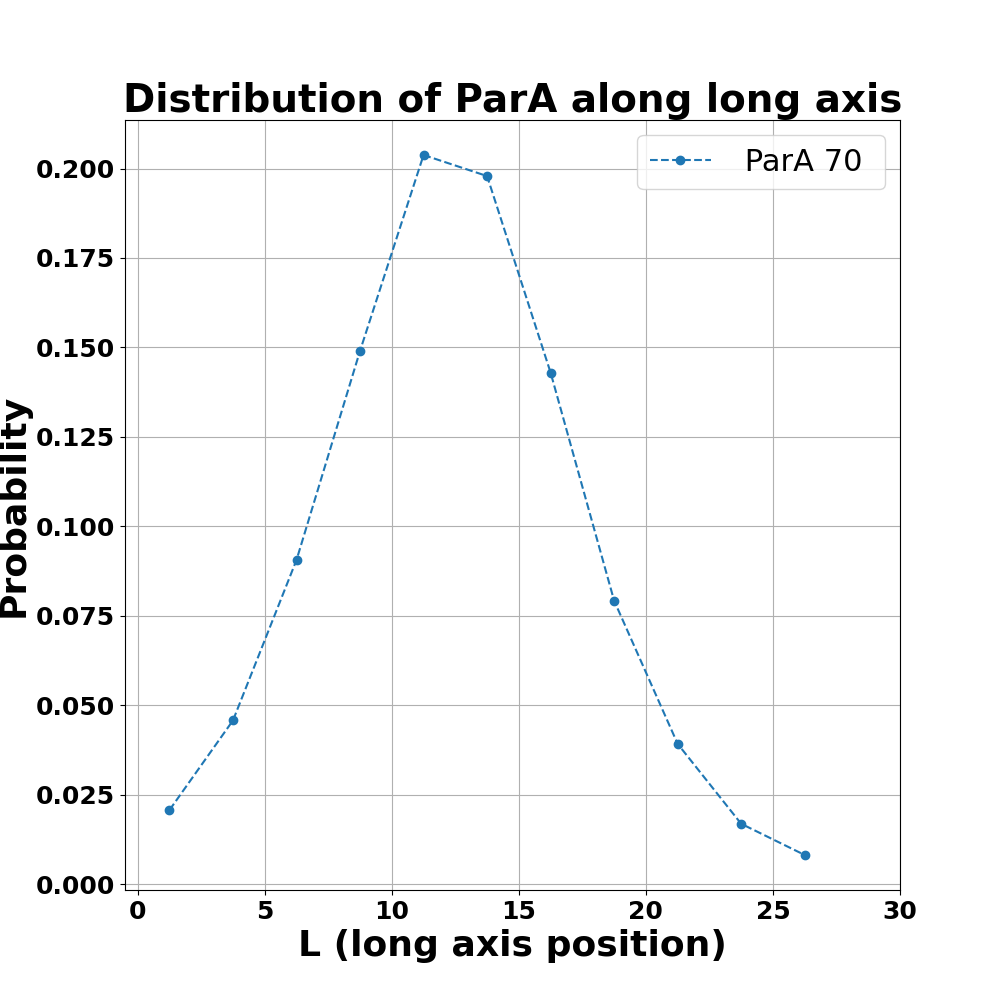

In [50]:
%matplotlib widget
num=0
traj_paths = [
    
    # "1000monruns/70ParA/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    # '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru',
    # "1000monruns/129ParA/A5soft_20k_8.50_fullring_1000_129_28_4_10krate_assym_popz_extru1",
    # "1000monruns/140ParA/A5soft_20k_8.50_fullring_1000_140_28_4_10krate_assym_popz_extru1",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1",
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1/initconfig',
    '1000monruns/150ParA/Gaussian/A5soft_20k_8.50_fullring_1000_150_28_4_10krate_extru_old_0.8',
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1',
    # '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru',
    # '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru'
]

lab=[' ParA 70 ',' ParA 100 ',' ParA 130 ',' ParA 160 ']
markers = ["o", "s",'^','x']
parnumbers=[70,100,130,160]
plt.figure(figsize=(10,10))
maxiter=120
l=0
for path in traj_paths:
    num=0
    zpos=[]
    for i in range(0,maxiter):
        file=gsd.hoomd.open(f'{path}/run_{i}_20k_3.50_fullringrepsoft.gsd',mode='r')
        # file=gsd.hoomd.open(f'{path}/run_{i}_20k_3.50_fullinitconf.gsd',mode='r')
        typeid=file[0].particles.typeid
        para=np.where(typeid==3)
        if len(para[0])!=160:
            print(f'for i={i},para={len(para[0])}')
        for n in para[0]:
            zpos.append(file[0].particles.position[n][2])

        num=num+len(para[0])
    num=num/maxiter
    # prob=plt.hist(zpos,bins=11,histtype='step',density=True)
    bins=[0+1.25,2.5+1.25,5+1.25,7.5+1.25,10+1.25,12.5+1.25,15+1.25,17.5+1.25,20+1.25,22.5+1.25,25+1.25,27.5+1.25]
    prob=np.histogram(zpos,bins=bins)
    # prob=plt.hist(zpos,bins=bins,histtype='step')
    simprob=prob[0]/maxiter/num
    # maxprob=max(parA-simprob)
    # scalingfactor=1/maxprob
    # plt.plot(prob[1][:-1],parA)
    plt.plot(prob[1][:-1],simprob[:],label=lab[l],marker=markers[l],linestyle= 'dashed')
    plt.legend(fontsize=22)
    plt.title("Distribution of ParA along long axis", fontweight='bold', fontsize=28)
    plt.xlim((-0.5,30))
    plt.xlabel('L (long axis position)', fontsize=26, fontweight='bold')
    plt.ylabel('Probability', fontsize=26, fontweight='bold')
    plt.tick_params(axis='both', labelsize=18)

    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontweight('bold')

    plt.grid(True)

    l=l+1
plt.savefig('1000monruns/ParAdist.png',dpi=300)
plt.savefig('1000monruns/ParAdist.eps',dpi=300)

In [ ]:
plt.savefig('1000monruns/ParAdist.pdf', bbox_inches='tight')

In [ ]:
%matplotlib widget

# plt.figure(figsize=(10,10))

prob=plt.hist(zpos,bins=11,histtype='step')
simprob=prob[0]/120/70
# maxprob=max(parA-simprob)
# scalingfactor=1/maxprob
# plt.figure(figsize=(10,10))
# plt.plot(parA)
plt.plot(simprob)

# plt.plot((parA-simprob)*scalingfactor)

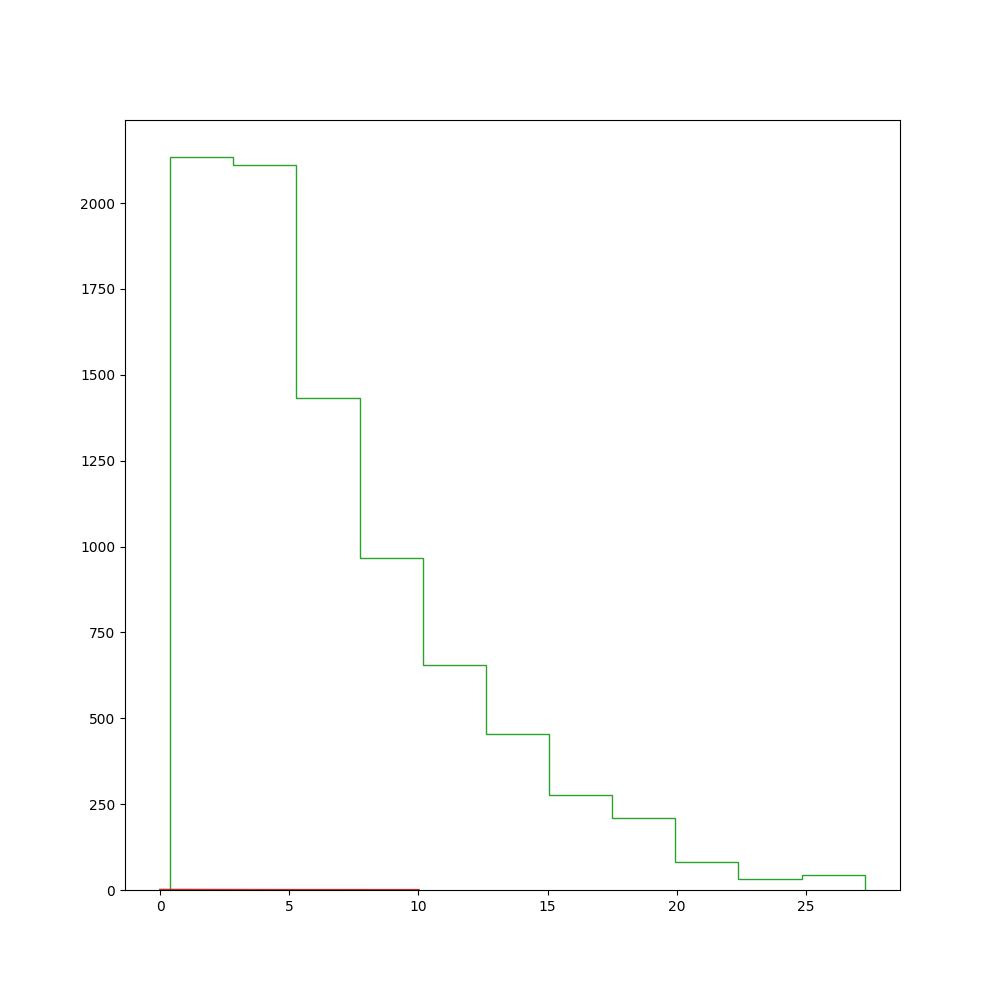

In [ ]:
plt.show()

In [ ]:
N=[70,100,129,160]
T=[0.2729375,0.22540545,0.1938894,0.171813636]


In [ ]:
N=[70,100,160]
T=[0.3152119,0.261189,0.2089]

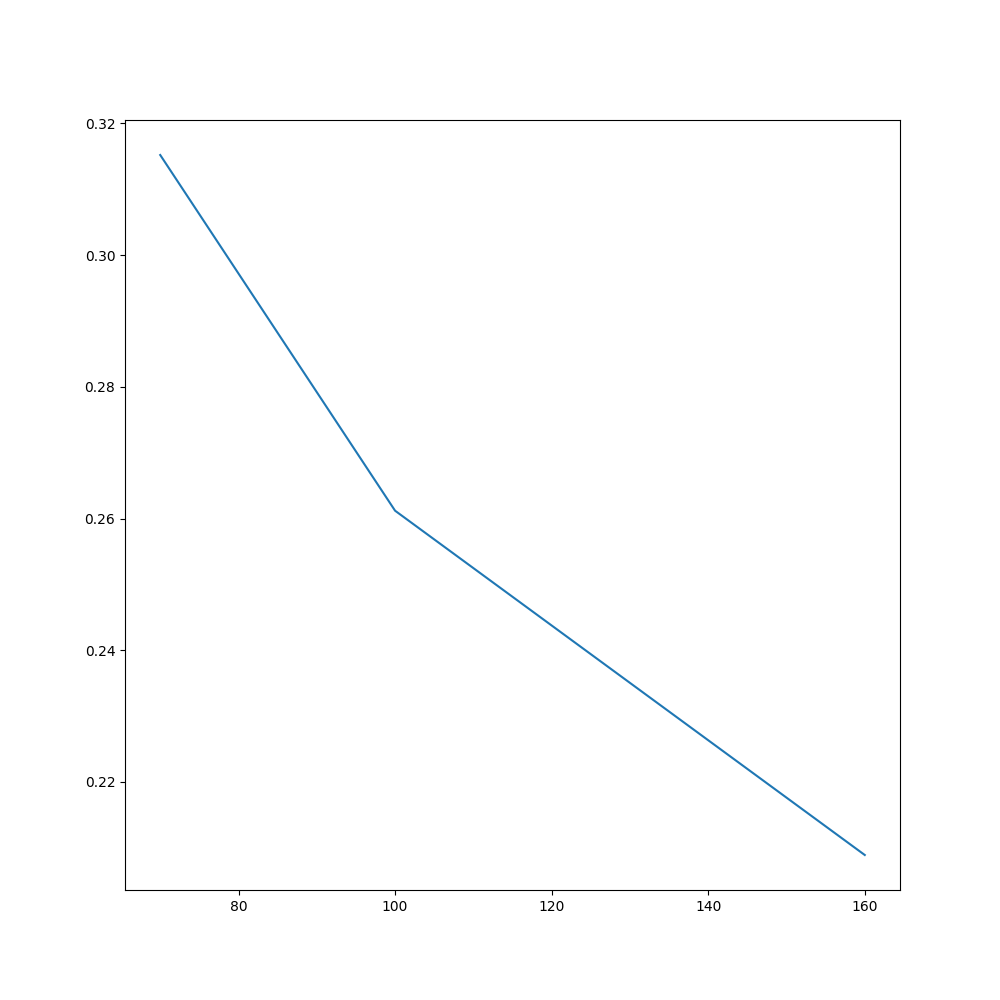

In [ ]:
plt.figure(figsize=(10,10))
plt.plot(N,T)
# plt.xscale('log')
# plt.yscale('log')


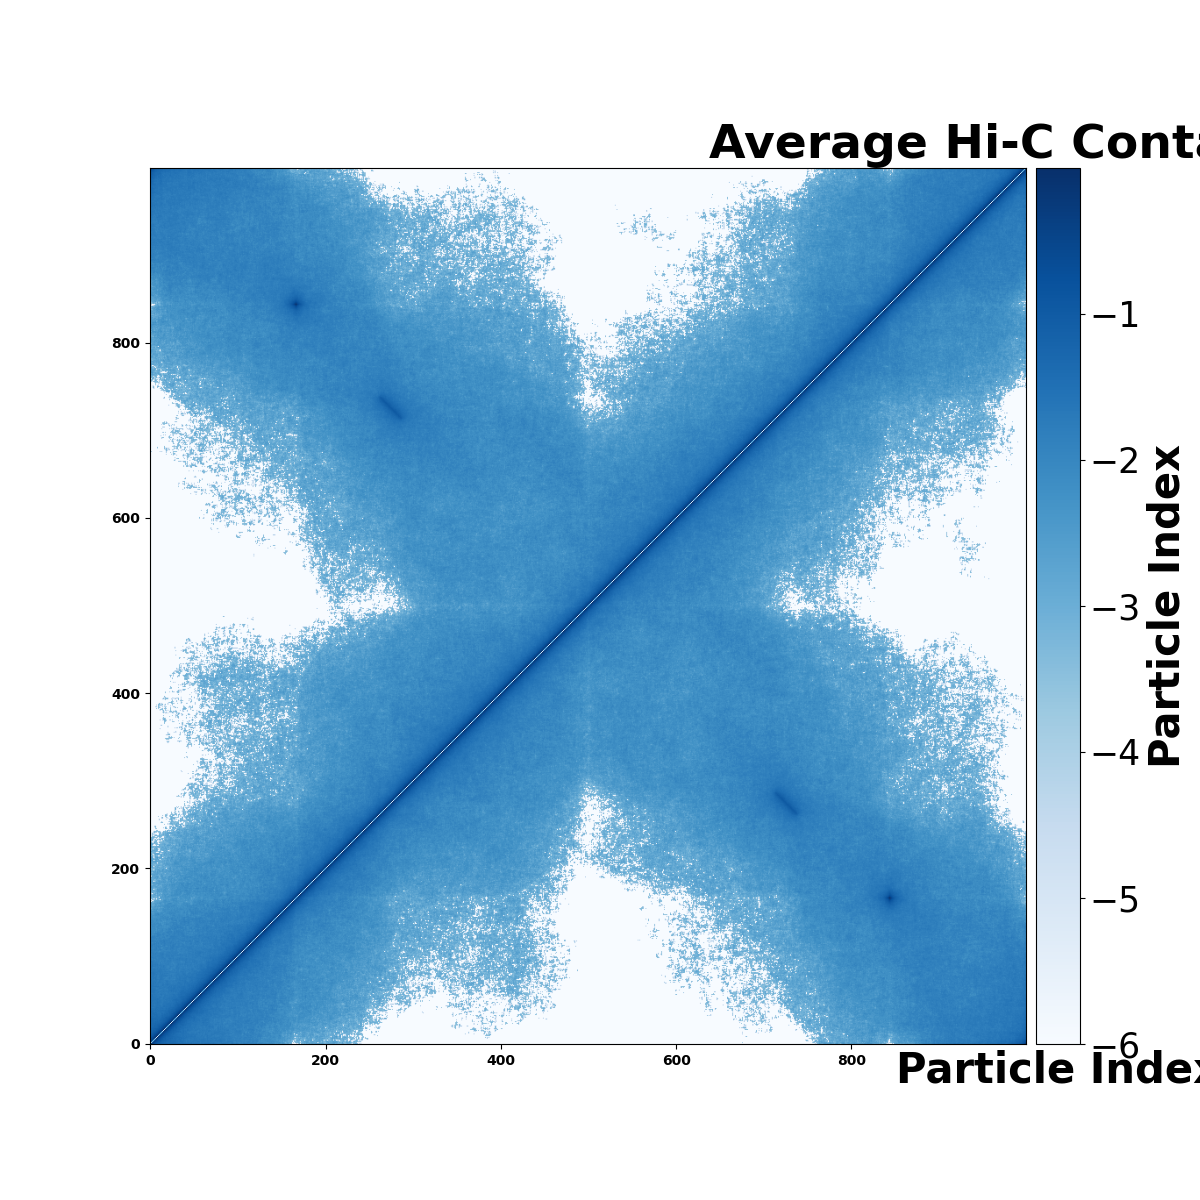

In [ ]:
plt.figure(figsize=(12, 12))
log_hic_map= np.load('1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/avg_hic_map3.npy')
# plt.imshow(avg_hic_map, cmap='Blues', interpolation='nearest', origin='lower')
log_hic_map=log_hic_map/200
# log_hic_map=(log_hic_map[:1000,:1000]+log_hic_map[2000:999:-1,2000:999:-1])/2
eps = 1e-6
log_hic_map = np.log10(log_hic_map + eps)
plt.imshow(log_hic_map[:1000,:1000], cmap='Blues',origin='lower')


cbar = plt.colorbar()
cbar.set_label('Average Contact Frequency (logscale)', fontsize=30, fontweight='bold')

plt.title(f'Average Hi-C Contact Map', fontsize=34, fontweight='bold')
plt.xlabel('Particle Index', fontsize=30, fontweight='bold')
plt.ylabel('Particle Index', fontsize=30, fontweight='bold')
plt.tick_params(axis='both', labelsize=25)

for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    label.set_fontweight('bold')
plt.savefig(
    '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru100_HiC_avg_log3.pdf',
    dpi=500
)
# np.save(
# '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/avg_hic_map2.npy',avg_hic_map)
# plt.show()

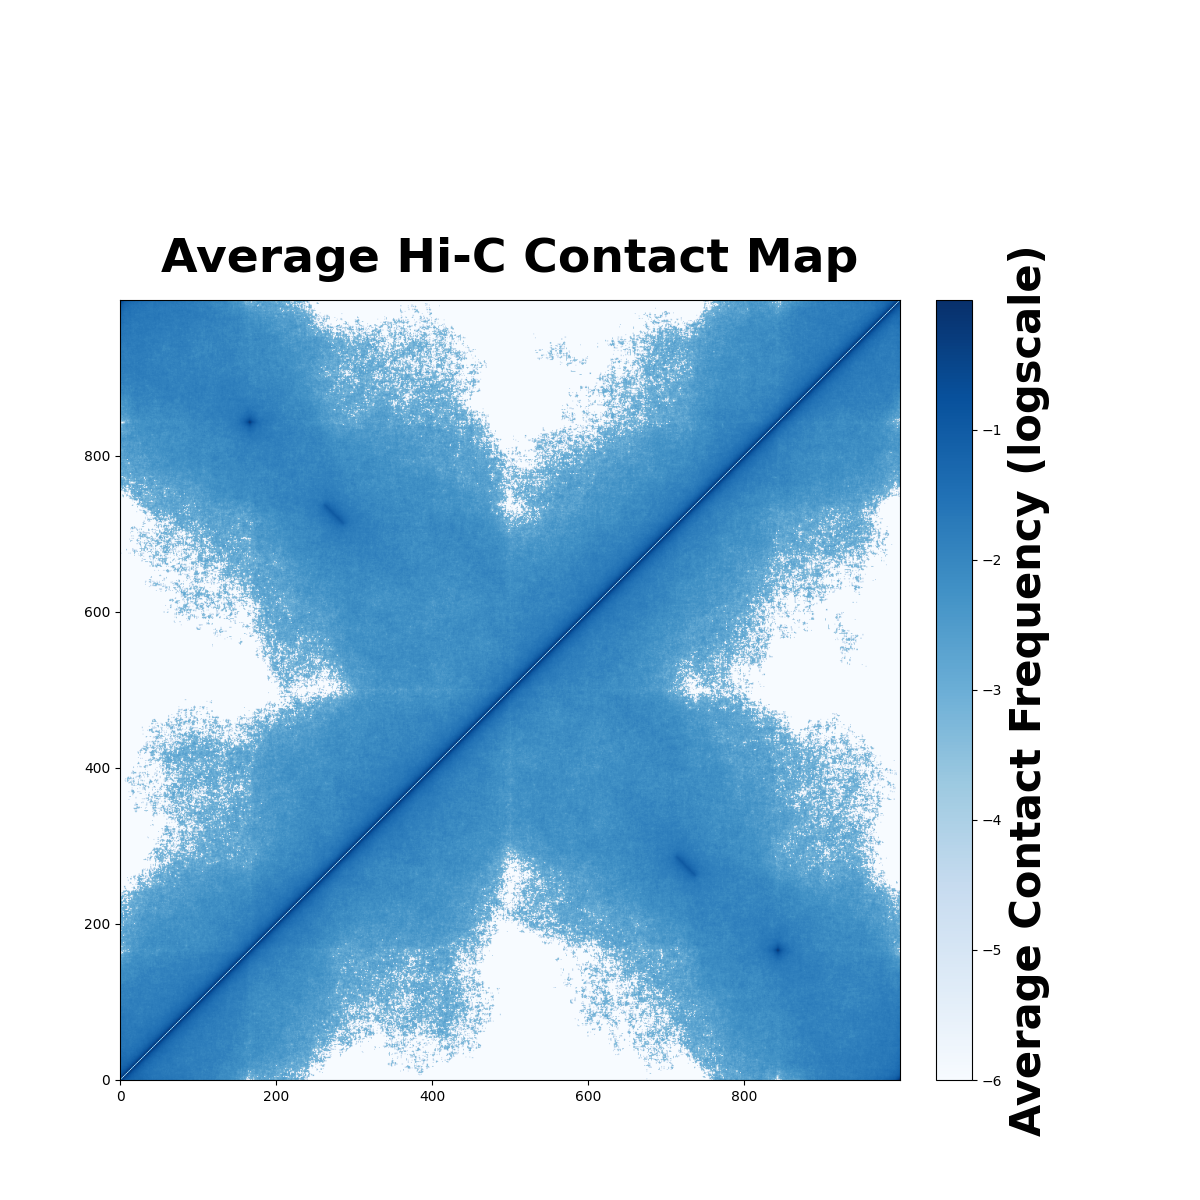

In [48]:
import matplotlib.pyplot as plt
import numpy as np

log_hic_map = np.load(
    '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru/avg_hic_map3.npy'
)

log_hic_map = log_hic_map / 200
log_hic_map = np.log10(log_hic_map + 1e-6)

fig = plt.figure(figsize=(12, 12))

# Create axis manually (gives full control)
ax = fig.add_axes([0.1, 0.1, 0.65, 0.65])  # left, bottom, width, height

im = ax.imshow(
    log_hic_map[:1000, :1000],
    cmap='Blues',
    origin='lower',
    aspect='equal'   
)

# Force square shape
ax.set_aspect('equal', adjustable='box')

# Add colorbar with EXACT same height
cax = fig.add_axes([0.78, 0.1, 0.03, 0.65])
cbar = fig.colorbar(im, cax=cax)

cbar.set_label(
    'Average Contact Frequency (logscale)',
    fontsize=30,
    fontweight='bold'
)

ax.set_title('Average Hi-C Contact Map',
             fontsize=34,
             fontweight='bold',
             pad=20)
plt.savefig(
    '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru100_HiC_avg_log3.pdf',
    dpi=500
)


In [48]:
import numpy as np 
traj_paths = [
    # "1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_ParAchange",
    # "1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_selfexclusion_extru",
    # "1000monruns/160ParA/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru",
    # "1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz",
    # "1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru",
    # '1000monruns/100ParA/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru'
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_5krate_extru_old_full',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_extru_old_full',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_20krate_extru_old_full',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_40krate_extru_old_full'
    # '1000monruns/Ringreplication/A5soft_20k_8.50_fullring_1000_70_28_4_assym_popz_extru'
    # '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz'
]

for path in traj_paths:
    iter,segtime=np.genfromtxt(f'{path}/seginfo.txt',unpack=True)
    print(len(iter)/240*100,np.mean(segtime),np.std(segtime))
    


40.0 0.44988541666666665 0.21979040061839158
44.166666666666664 0.42233490566037735 0.19122181284080322
56.25 0.418225925925926 0.18378246720993896
73.33333333333333 0.44437499999999996 0.2026535648083829


In [72]:
import numpy as np
import pandas as pd
import os

traj_paths = [
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_5krate_extru_old_full',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_extru_old_full',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_20krate_extru_old_full',
    '1000monruns/100ParA/expo/entropycheck/A5soft_20k_8.50_fullring_1000_100_28_4_40krate_extru_old_full'
]

rows = []

for path in traj_paths:
    iteration, segtime = np.genfromtxt(f'{path}/seginfo.txt', unpack=True)

    rows.append({
        "Simulation": os.path.basename(path),
        "Success (%)": len(iteration) / 240 * 100,
        "Mean Seg. Time": np.mean(segtime),
        "Std. Dev.": np.std(segtime)
    })
    # plt.figure(figsize=(10,10))
    # plt.plot(segtime,'.')
    # plt.show()
df = pd.DataFrame(rows)

# Display nicely
print(df.to_string(index=False))

# Optional: save to CSV
df.to_csv("1000monruns/100ParA/expo/entropycheck/segregation_summary.csv", index=False)

                                                   Simulation  Success (%)  Mean Seg. Time  Std. Dev.
 A5soft_20k_8.50_fullring_1000_100_28_4_5krate_extru_old_full    40.000000        0.449885   0.219790
A5soft_20k_8.50_fullring_1000_100_28_4_10krate_extru_old_full    44.166667        0.422335   0.191222
A5soft_20k_8.50_fullring_1000_100_28_4_20krate_extru_old_full    56.250000        0.418226   0.183782
A5soft_20k_8.50_fullring_1000_100_28_4_40krate_extru_old_full    73.333333        0.444375   0.202654


In [73]:
import pandas as pd

df = pd.read_csv("1000monruns/100ParA/expo/entropycheck/segregation_summary.csv")

latex = df.to_latex(
    index=False,
    float_format="%.4f",
    caption="Segregation statistics",
    label="tab:segstats",
    escape=False
)

print(latex)

with open("1000monruns/100ParA/expo/entropycheck/segregation_summary.tex", "w") as f:
    f.write(latex)

\begin{table}
\centering
\caption{Segregation statistics}
\label{tab:segstats}
\begin{tabular}{lrrr}
\toprule
                                        Simulation &  Success (%) &  Mean Seg. Time &  Std. Dev. \\
\midrule
A5soft_20k_8.50_fullring_1000_100_28_4_5krate_e... &      40.0000 &          0.4499 &     0.2198 \\
A5soft_20k_8.50_fullring_1000_100_28_4_10krate_... &      44.1667 &          0.4223 &     0.1912 \\
A5soft_20k_8.50_fullring_1000_100_28_4_20krate_... &      56.2500 &          0.4182 &     0.1838 \\
A5soft_20k_8.50_fullring_1000_100_28_4_40krate_... &      73.3333 &          0.4444 &     0.2027 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_7625/1704717149.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df.to_latex(


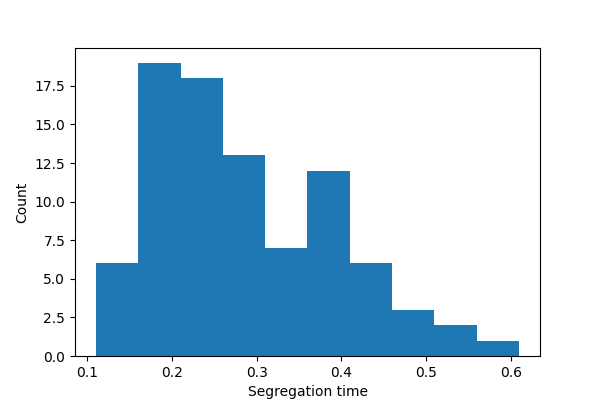

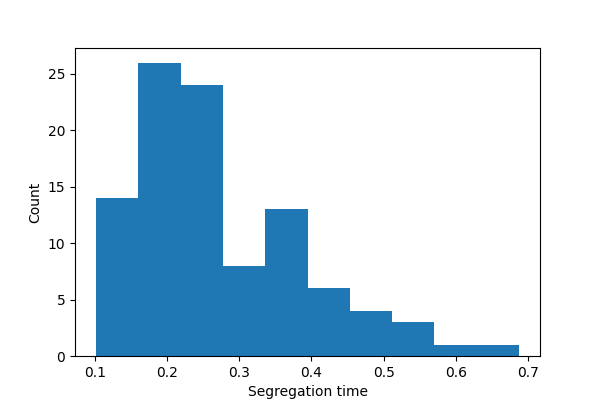

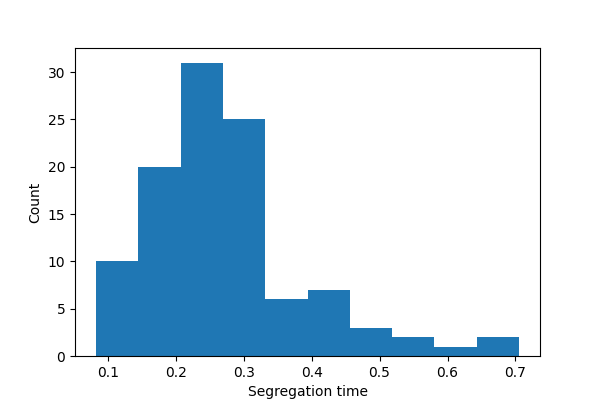

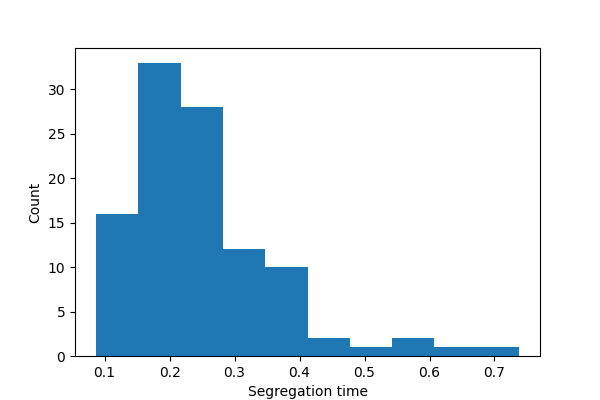

                                                      Simulation  Success (%)  Mean Seg. Time  Std. Dev.
 A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1    72.500000        0.285247   0.106865
A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1    83.333333        0.272415   0.119232
A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1    89.166667        0.271318   0.119485
A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1    88.333333        0.250467   0.111781


In [68]:
import numpy as np
import pandas as pd
import os

traj_paths = [
    '1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1',
    '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1',
    '1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1',
    '1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1'
]

rows = []

for path in traj_paths:
    iteration, segtime = np.genfromtxt(f'{path}/seginfo.txt', unpack=True)

    rows.append({
        "Simulation": os.path.basename(path),
        "Success (%)": len(iteration) / 120 * 100,
        "Mean Seg. Time": np.mean(segtime),
        "Std. Dev.": np.std(segtime)
    })
    plt.figure(figsize=(6,4))
    plt.hist(segtime, bins=10)
    plt.xlabel("Segregation time")
    plt.ylabel("Count")
    plt.show()

df = pd.DataFrame(rows)

# Display nicely
print(df.to_string(index=False))

# Optional: save to CSV
df.to_csv("1000monruns/100ParA/expo/segregation_summary.csv", index=False)

In [70]:
import pandas as pd

df = pd.read_csv("1000monruns/150ParA/expo/segregation_summary.csv")

latex = df.to_latex(
    index=False,
    float_format="%.4f",
    caption="Segregation statistics",
    label="tab:segstats",
    escape=False
)

print(latex)

with open("1000monruns/150ParA/expo/segregation_summary.tex", "w") as f:
    f.write(latex)

\begin{table}
\centering
\caption{Segregation statistics}
\label{tab:segstats}
\begin{tabular}{lrrr}
\toprule
                                        Simulation &  Success (%) &  Mean Seg. Time &  Std. Dev. \\
\midrule
A5soft_20k_8.50_fullring_1000_150_28_4_5krate_e... &      50.0000 &          0.3427 &     0.1384 \\
A5soft_20k_8.50_fullring_1000_150_28_4_10krate_... &      62.5000 &          0.3382 &     0.1558 \\
A5soft_20k_8.50_fullring_1000_150_28_4_20krate_... &      72.5000 &          0.4101 &     0.2083 \\
A5soft_20k_8.50_fullring_1000_150_28_4_40krate_... &      79.1667 &          0.3721 &     0.1347 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_7625/895902868.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df.to_latex(


In [64]:
%matplotlib widget
import numpy as np 
import matplotlib.pyplot as plt
import gsd.hoomd as gh


file=f'outputtrajs/loci_traj_5_10001.gsd'

traj= gh.open(name=file,mode='r')

indx=int(86*500/180)
locis=[0,244,364,476]
posdata=np.zeros((4,2002))

for i in range(len(traj)):
    for j in range(len(locis)):
        posdata[j][i]=(traj[i].particles.position[locis[j]][2]/28)
        


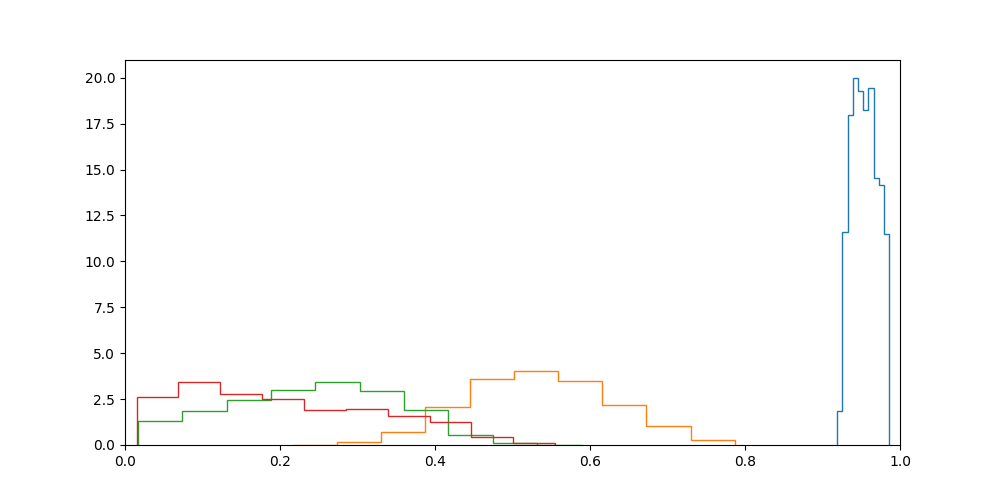

In [65]:
plt.figure(figsize=(10,5))
for j in range(len(locis)):
    plt.hist(posdata[:][j],histtype='step',density=True)
plt.xlim((0,1))
plt.show()

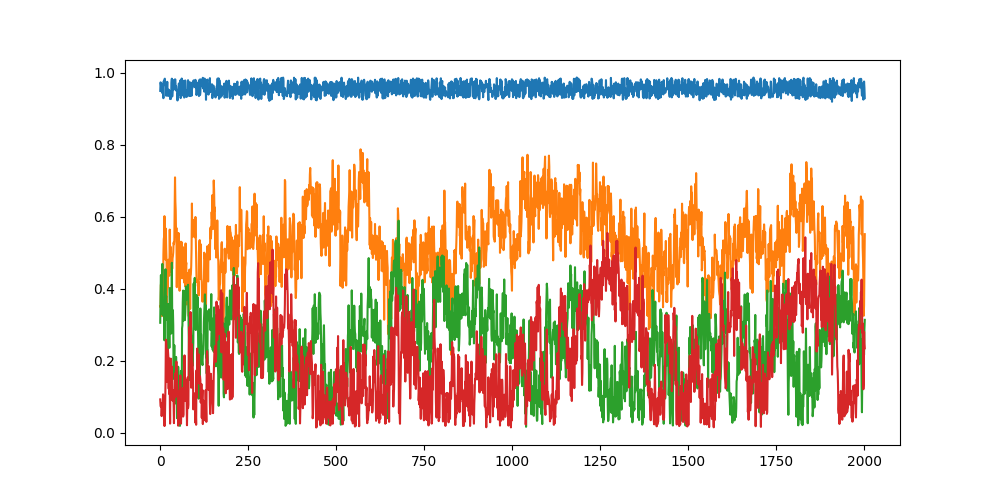

In [67]:
plt.figure(figsize=(10,5))
for j in range(len(locis)):
    plt.plot(posdata[:][j])
# plt.xlim((0,1))
plt.show()

2400


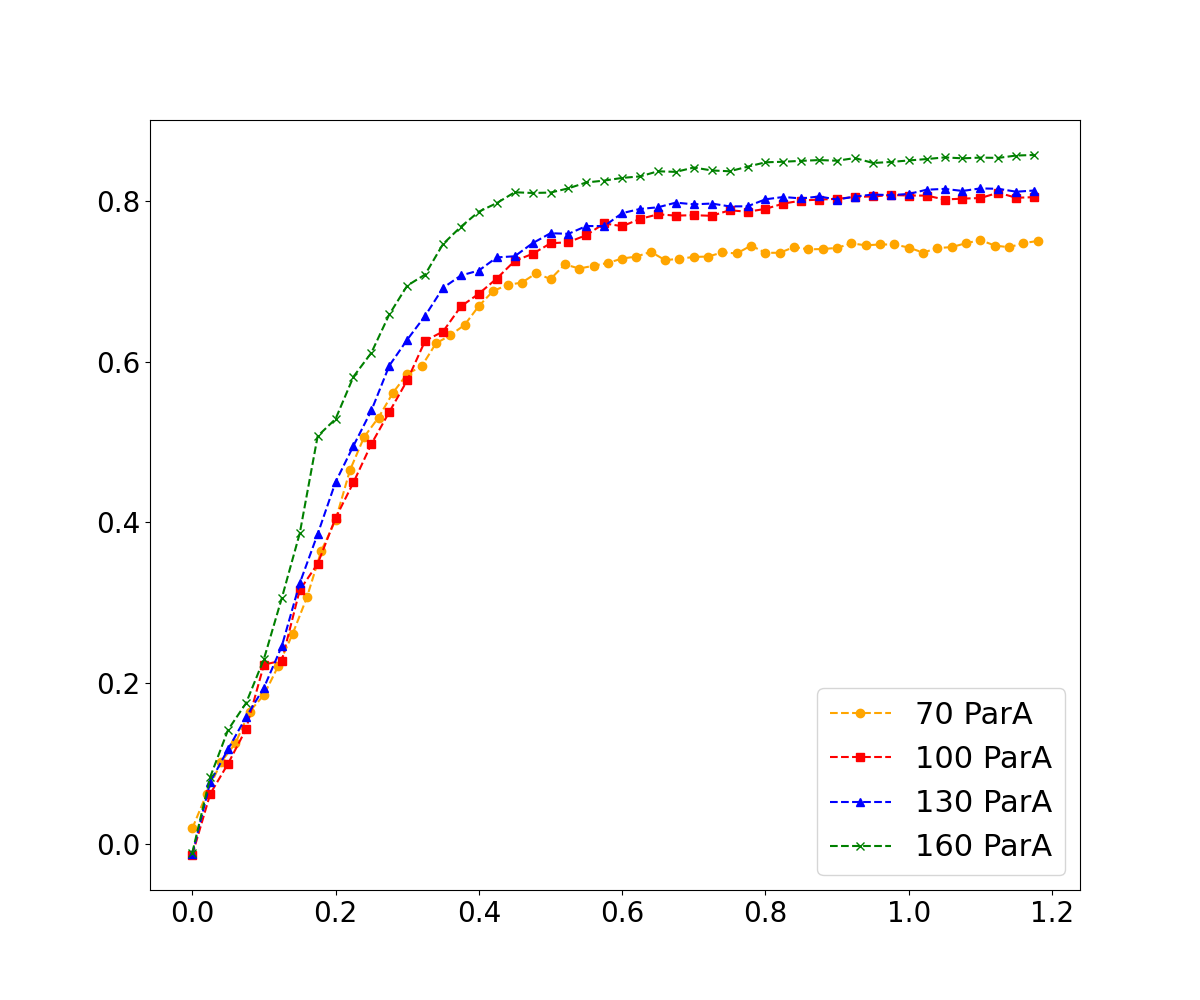

In [112]:
filepaths=[
'1000monruns/70ParA/expo/A5soft_20k_8.50_fullring_1000_70_28_4_10krate_assym_popz_extru1/avgoridata.npy',
# '1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1/avgoridata.npy',
'1000monruns/100ParA/expo/A5soft_20k_8.50_fullring_1000_100_28_4_10krate_assym_popz_extru1/traj/240avgori.npy',
'1000monruns/130ParA/expo/A5soft_20k_8.50_fullring_1000_130_28_4_10krate_assym_popz_extru1/traj/240avgori.npy',
'1000monruns/160ParA/expo/A5soft_20k_8.50_fullring_1000_160_28_4_10krate_assym_popz_extru1/traj/240avgori.npy'


]
labels=['70 ParA','100 ParA','130 ParA','160 ParA']
color=['orange','red','blue','green']
markers = ["o", "s",'^','x']
plt.figure(figsize=(12,10))
i=0
for path,lab,col,mark in zip(filepaths,labels,color,markers):

    if i>0:
        time,avgori=np.load(f'{path}')
        plt.plot(time[::50],avgori[::50],linestyle='dashed',label=lab,color=col,marker=mark)
    else:
        time,avgori=np.load(f'{path}')
        plt.plot(time[::2],avgori[::2],linestyle='dashed',label=lab,color=col,marker=mark)
    i+=1

print(len(time))
plt.legend(fontsize=22)
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()


